# Infraslow oscillation — relative spectral power across channels (data, stage N2)

Reads the pipeline's own bout-averaged, baseline-corrected infraslow spectrum
(`{channel}__spectra__corr_mean` vs. `{channel}__spectra__freqs`) directly from
`$SCRATCH/data/npz/{STAGE}/{SUBJECT}.npz` — the same npz layout as
`$SCRATCH/verify_318658/npz/{STAGE}/{SUBJECT}.npz` used in this notebook's earlier
old-vs-new comparison. No raw EDF, hypnogram, or fresh Welch computation needed here.

For each of the 6 channels (F3, F4, C3, C4, O1, O2), one subplot shows every subject's
individual corrected spectrum as a thin line behind the across-subject average (± SEM)
drawn on top — matching the left ("relative spectral power") panel style of
`demo_infraslow_yasa_average.ipynb`, without the Gaussian ISFS fit.

`data` is a live, growing cohort snapshot (the `all_metrics` Slurm job is still
writing new subjects). By default (`N_SUBJECTS = None`) this notebook loads every
subject npz file found in the stage directory at run time, so re-running later will
pick up newly-added files as the job progresses; set `N_SUBJECTS` to an integer to
cap the cohort to the first N sorted subjects instead (useful while iterating).

In [ ]:
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from infraslow.processing.subject_pipeline import INFRASLOW_BAND, BASELINE_BAND

plt.rcParams['figure.dpi'] = 110
CHANNELS = ['F3', 'F4', 'C3', 'C4', 'O1', 'O2']
STAGES = ['N1', 'N2', 'N3', 'NREM']
SINGLE_STAGE = 'N2'   # stage used for the single-stage figure below
STAGE_COLORS = {'N1': '#ff7f0e', 'N2': '#5b2a86', 'N3': '#1f77b4', 'NREM': '#2ca02c'}
SUBJ_COLOR = '0.6'
_trapz = getattr(np, 'trapezoid', np.trapz)   # NumPy 2.0 renamed trapz

# UI styling (scaled down from plot_infraslow.ipynb's for this notebook's denser 2x3 grid)
TITLE_FONTSIZE = 11
LABEL_FONTSIZE = 9
TICK_FONTSIZE = 8
LEGEND_FONTSIZE = 7
ANNOTATION_FONTSIZE = 7
SUPTITLE_FONTSIZE = 15

N_SUBJECTS = 10   # None = every subject npz found for a stage (not just the first N)
SHOW_INDIVIDUAL = False
RESULTS_DIR = Path(os.path.expandvars('$SCRATCH/data/npz'))
# Opening/decoding a .npz is dominated by Lustre I/O latency, not CPU, and a
# blocking read releases the GIL, so more threads than cores still overlaps more
# latency (see plot_infraslow.ipynb) -- matters once N_SUBJECTS is None and a
# stage has 70k+ subject files.
N_IO_WORKERS = min(32, len(os.sched_getaffinity(0)) * 4)

## Load spectra, plus a bi-Gaussian ISFS fit + shared subplot helper

`load_stage_cohort` loads the first `N_SUBJECTS` sorted subject npz files for one
stage. `fit_isfs`/`bigaussian` mirror `plot_infraslow.ipynb`'s asymmetric bi-Gaussian
fit (independent left/right SDs sharing one peak, with `mu` pinned to the empirical
argmax — too few points in the fit window to also let a 4th free parameter float).
`plot_channel_subplot` draws one channel's subject lines + average ± SEM + bi-Gaussian
fit, and is reused by both the single-stage and per-stage-figure cells below.

In [6]:
def _spindle_rate_per_min(npz, ch):
    """Spindles/min for ONE subject/channel: total `{ch}__bouts__n_spindles` over
    total bout duration (`{ch}__bouts__stop` - `{ch}__bouts__start`, seconds), or NaN
    if there are no bouts for this channel. This collapses all of a subject's bouts
    into a single per-subject rate -- callers must average these per-subject rates
    across subjects (not pool raw per-bout counts across subjects), otherwise
    subjects with more/longer bouts would be over-weighted relative to subjects with
    fewer bouts."""
    nkey, skey, ekey = f'{ch}__bouts__n_spindles', f'{ch}__bouts__start', f'{ch}__bouts__stop'
    if nkey not in npz.files or skey not in npz.files or ekey not in npz.files:
        return np.nan
    n_spindles, start, stop = npz[nkey], npz[skey], npz[ekey]
    if n_spindles.size == 0:
        return np.nan
    total_sec = float((stop - start).sum())
    if total_sec <= 0:
        return np.nan
    return float(n_spindles.sum()) / (total_sec / 60.0)


def load_subject_spectra(npz_path, channels):
    """{channel: (freqs, corr_mean, spindle_rate_per_min)} for channels with a
    non-empty spectrum in this npz."""
    out = {}
    with np.load(npz_path) as npz:
        for ch in channels:
            fkey, ckey = f'{ch}__spectra__freqs', f'{ch}__spectra__corr_mean'
            if fkey not in npz.files or ckey not in npz.files:
                continue
            freqs = npz[fkey]
            if freqs.size == 0:
                continue
            out[ch] = (freqs, npz[ckey], _spindle_rate_per_min(npz, ch))
    return out


def load_stage_cohort(stage, channels, n_subjects):
    """by_channel[ch] = {'freqs': shared freq grid, 'subjects': {subject_id: corr_mean},
    'spindle_rate': {subject_id: spindles/min}} for the first n_subjects subject npz
    files (sorted by id) found for this stage, or every file if n_subjects is None.
    Loads run across N_IO_WORKERS threads (I/O-bound, a blocking read releases the
    GIL) -- matters once a stage has 70k+ subject files. by_channel['_n_files'] holds
    the actual file count used (for titles/labels), since it can differ from
    n_subjects and even between stages when n_subjects is None."""
    stage_dir = RESULTS_DIR / stage
    all_paths = sorted(stage_dir.glob('*.npz'))
    subject_paths = all_paths[:n_subjects] if n_subjects else all_paths
    print(f'{stage}: using {len(subject_paths)} of {len(all_paths)} available subject npz files')

    by_channel = {ch: {'freqs': None, 'subjects': {}, 'spindle_rate': {}} for ch in channels}
    with ThreadPoolExecutor(max_workers=N_IO_WORKERS) as pool:
        loaded = pool.map(lambda p: (p.stem, load_subject_spectra(p, channels)), subject_paths)
        for sid, per_channel in loaded:
            for ch, (freqs, corr, rate) in per_channel.items():
                entry = by_channel[ch]
                if entry['freqs'] is None:
                    entry['freqs'] = freqs
                elif not np.array_equal(entry['freqs'], freqs):
                    print(f'skip {stage}/{sid} {ch}: frequency grid differs from the rest of the cohort')
                    continue
                entry['subjects'][sid] = corr
                entry['spindle_rate'][sid] = rate
    by_channel['_n_files'] = len(subject_paths)
    return by_channel


def bigaussian(f, amp, mu, sd_l, sd_r):
    """Two Gaussian halves sharing one peak but independent left/right widths --
    captures the asymmetric shape (steep rise, slow decay) real infraslow spectra
    show, which a symmetric Gaussian would pull away from the true peak to compromise on."""
    sd = np.where(f < mu, sd_l, sd_r)
    return amp * np.exp(-0.5 * ((f - mu) / sd) ** 2)


def fit_isfs(freqs, corrected, infraslow_band=INFRASLOW_BAND, baseline_band=BASELINE_BAND):
    """Bi-Gaussian ISFS fit (peak, bandwidth, AUC, detection) with `mu` fixed at the
    empirical argmax -- see plot_infraslow.ipynb's fit_isfs for why (too few points
    in the fit window to also let a 4th free parameter float)."""
    base_m = (freqs >= baseline_band[0]) & (freqs <= baseline_band[1])
    fit_m = (freqs >= infraslow_band[0]) & (freqs < baseline_band[0])
    ff, yy = freqs[fit_m], corrected[fit_m]
    mu = float(ff[np.argmax(yy)])

    def _bigaussian_fixed_mu(f, amp, sd_l, sd_r):
        return bigaussian(f, amp, mu, sd_l, sd_r)

    p0 = [max(yy.max(), 1e-9), 0.01, 0.01]
    (amp, sd_l, sd_r), _ = curve_fit(_bigaussian_fixed_mu, ff, yy, p0=p0,
                                     bounds=([0, 1e-3, 1e-3], [np.inf, 0.05, 0.05]),
                                     maxfev=10000)
    popt = (amp, mu, sd_l, sd_r)
    lo, hi = mu - sd_l, mu + sd_r
    bandwidth = hi - lo
    f_auc = np.linspace(lo, hi, 400)
    auc = float(_trapz(bigaussian(f_auc, *popt), f_auc))
    threshold = 1.5 * corrected[base_m].std()
    return dict(popt=popt, amp=amp, mu=mu, sd_l=sd_l, sd_r=sd_r, lo=lo, hi=hi,
                bandwidth=bandwidth, auc=auc, threshold=threshold,
                detected=bool(amp > threshold))


def _threshold_crossing(curve_freqs, curve, start_idx, threshold=0.0):
    """First frequency, at or after `start_idx`, where `curve` drops from >=
    `threshold` to < `threshold`, linearly interpolated between the two
    bracketing samples (see plot_infraslow.ipynb)."""
    seg = curve[start_idx:]
    crossings = np.flatnonzero((seg[:-1] >= threshold) & (seg[1:] < threshold))
    if crossings.size == 0:
        return float(curve_freqs[-1])
    i = start_idx + int(crossings[0])
    f_a, f_b = curve_freqs[i], curve_freqs[i + 1]
    y_a, y_b = curve[i], curve[i + 1]
    return float(f_a + (threshold - y_a) * (f_b - f_a) / (y_b - y_a))


def chromatogram_peak_area(curve_freqs, curve, threshold=0.0, infraslow_band=INFRASLOW_BAND):
    """Chromatogram-style peak area: `curve` integrated above a sloped baseline
    from (infraslow_band[0], curve there) down to where `curve` drops to
    `threshold` (see plot_infraslow.ipynb)."""
    x0 = infraslow_band[0]
    y0 = float(np.interp(x0, curve_freqs, curve))
    peak_idx = int(np.argmax(curve))
    x1 = _threshold_crossing(curve_freqs, curve, peak_idx, threshold)

    peak_m = (curve_freqs >= x0) & (curve_freqs <= x1)
    xf, yf = curve_freqs[peak_m], curve[peak_m]
    incline = threshold + (y0 - threshold) * (x1 - xf) / (x1 - x0)
    above = np.clip(yf - incline, 0, None)
    area = float(_trapz(above, xf))
    return dict(area=area, freqs=xf, curve=yf, incline=incline, x0=x0, y0=y0, x1=x1,
                threshold=threshold)


def plot_channel_subplot(ax, freqs, subj_corr, title, *, color, spindle_rates=None, show_individual=False, show_legend=False):
    """Subject lines behind, average +/- SEM on top, plus a bi-Gaussian ISFS fit
    (on the average curve) with its peak/bandwidth/AUC annotated. Returns
    {'fit': fit_isfs(...), 'peak_area': chromatogram_peak_area(...)['area'], 'n': n,
    'spindle_per_min': mean spindles/min across subjects, 'spindle_per_min_sem': its
    SEM} (or None if there's no data / the fit failed) so the caller can build a
    summary table and compare peak power across channels."""
    if freqs is None or not subj_corr:
        ax.set_title(f'{title} (no data)', fontsize=TITLE_FONTSIZE)
        ax.axis('off')
        return None

    band_m = (freqs >= INFRASLOW_BAND[0]) & (freqs <= INFRASLOW_BAND[1])
    stack = np.vstack(list(subj_corr.values()))
    mean = stack.mean(0)
    n = len(stack)
    sem = stack.std(0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(mean)
    if show_individual:
        for i, corr in enumerate(subj_corr.values()):
            ax.plot(freqs[band_m], corr[band_m], color=SUBJ_COLOR, lw=0.8, alpha=0.5,
                    zorder=1, label='individual subjects' if i == 0 else None)
    ax.fill_between(freqs[band_m], (mean - sem)[band_m], (mean + sem)[band_m],
                     color=color, alpha=0.2, zorder=2, label='SEM')
    ax.axhline(0.0, ls=":", color="0.3", label="Baseline (0)",
    )
    ax.plot(freqs[band_m], mean[band_m], color=color, lw=2.0, zorder=3,
            label=f'Average (n={n})')

    # `spindle_rates` already holds ONE rate per subject (bouts averaged within that
    # subject by `_spindle_rate_per_min`) -- averaging those per-subject rates here
    # (rather than pooling raw per-bout spindle counts across subjects) keeps every
    # subject weighted equally regardless of how many bouts it contributed.
    spindle_vals = np.array(list(spindle_rates.values()), dtype=float) if spindle_rates else np.array([])
    spindle_vals = spindle_vals[np.isfinite(spindle_vals)]
    if spindle_vals.size > 0:
        spindle_per_min = float(spindle_vals.mean())
        spindle_per_min_sem = (float(spindle_vals.std(ddof=1) / np.sqrt(spindle_vals.size))
                                if spindle_vals.size > 1 else 0.0)
    else:
        spindle_per_min = spindle_per_min_sem = np.nan

    try:
        fit = fit_isfs(freqs, mean)
    except RuntimeError:
        fit = None

    result = None
    if fit is not None:
        fg = np.linspace(*INFRASLOW_BAND, 200)
        fitted_curve = bigaussian(fg, *fit['popt'])
        ax.plot(fg, fitted_curve, color='k', lw=1.6, zorder=4, label='bi-Gaussian fit')
        ax.plot([fit['mu']], [fit['amp']], 'o', color='k', ms=5, zorder=5)
        rate_line = (f"{spindle_per_min:.2f}±{spindle_per_min_sem:.2f} spindles/min"
                     if np.isfinite(spindle_per_min) else "")
        ax.text(0.97, 0.75,
                f"peak {fit['mu']:.4f} Hz (~{1 / fit['mu']:.0f} s)\n{rate_line}",
                # f"bandwidth {fit['bandwidth']:.4f} Hz\nAUC {fit['auc']:.3g}",
                transform=ax.transAxes, ha='right', va='top', fontsize=ANNOTATION_FONTSIZE,
                bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.85))
        peak = chromatogram_peak_area(fg, fitted_curve, threshold=fit['threshold'])
        result = dict(fit=fit, peak_area=peak['area'], n=n,
                      spindle_per_min=spindle_per_min, spindle_per_min_sem=spindle_per_min_sem)

    ax.set_xlim(INFRASLOW_BAND)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight='semibold', pad=8)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE, length=4, width=1)
    ax.grid(True, which='major', axis='both', linestyle='--', linewidth=0.6, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if show_legend:
        ax.legend(frameon=True, fontsize=LEGEND_FONTSIZE, borderpad=0.7,
                  labelspacing=0.4, loc='upper right')
    return result

## All stages — one figure per stage, bi-Gaussian fit per channel

Same idea as the single-stage figure above, but one separate figure per stage
(`N1`, `N2`, `N3`, `NREM`), each with the same 6-channel subplot grid and
per-channel bi-Gaussian fit. Reuses `load_stage_cohort`/`plot_channel_subplot`
defined above; each stage gets its own cohort (all subjects by default, or the
first `N_SUBJECTS` if that's set to an integer), drawn independently from that
stage's directory, so both the subject set and the count can differ stage to
stage.

In [3]:
by_stage = {stage: load_stage_cohort(stage, CHANNELS, N_SUBJECTS) for stage in STAGES}

N1: using 10 of 166449 available subject npz files
N2: using 10 of 166449 available subject npz files
N3: using 10 of 166449 available subject npz files
NREM: using 10 of 166449 available subject npz files


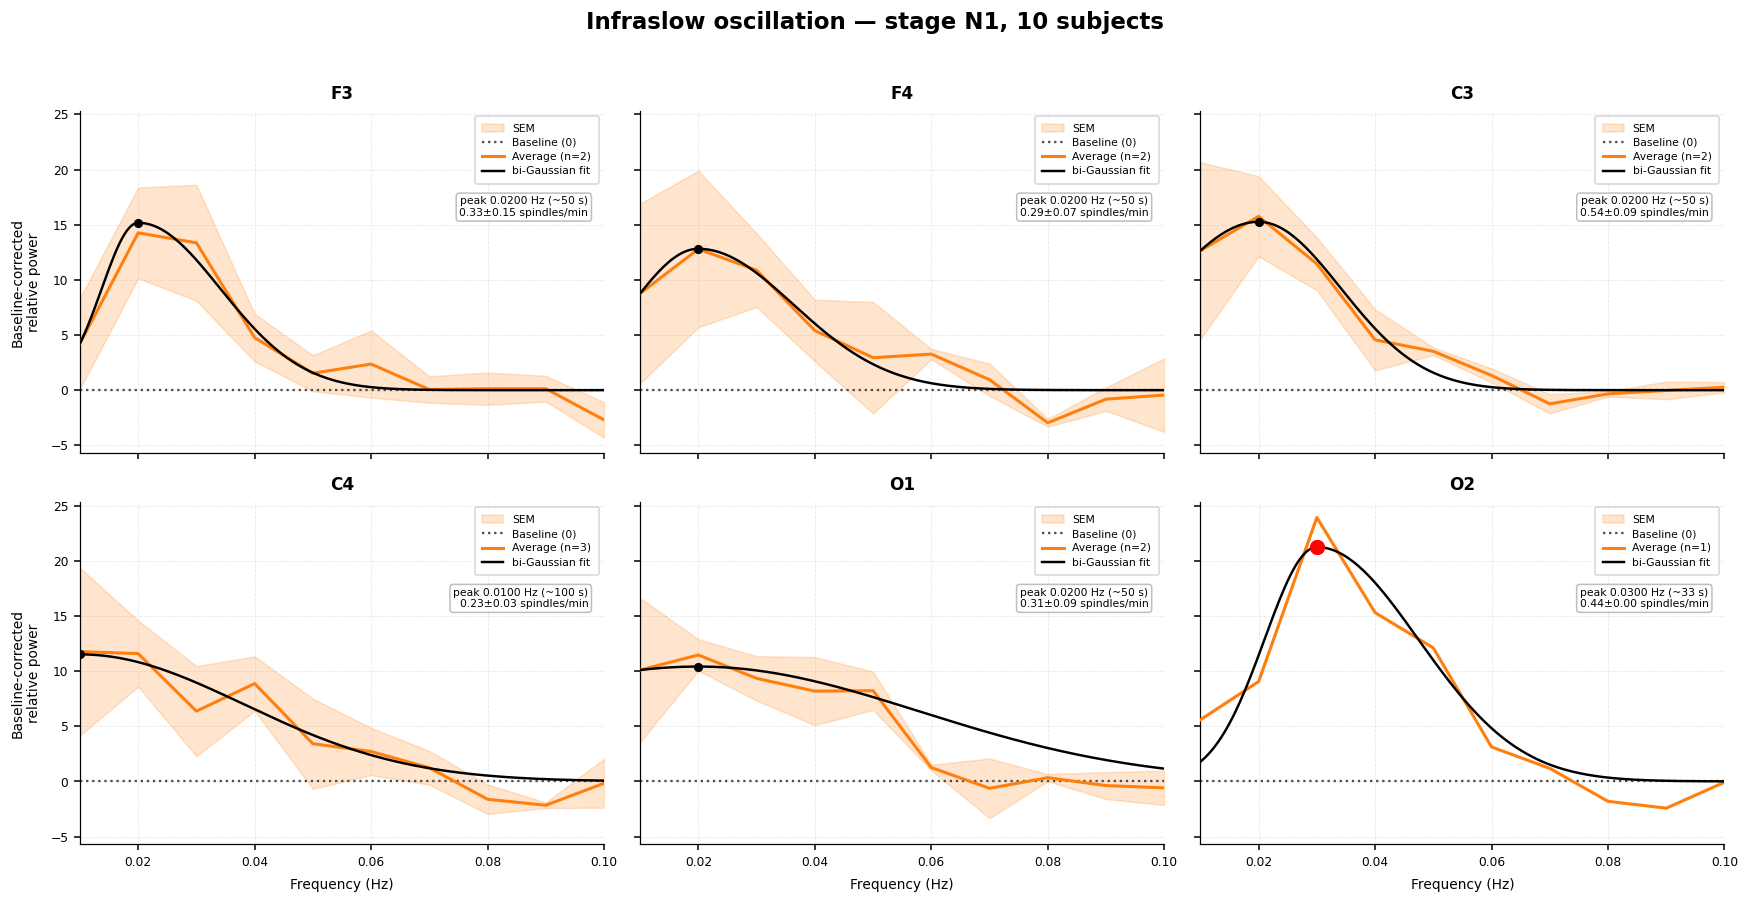

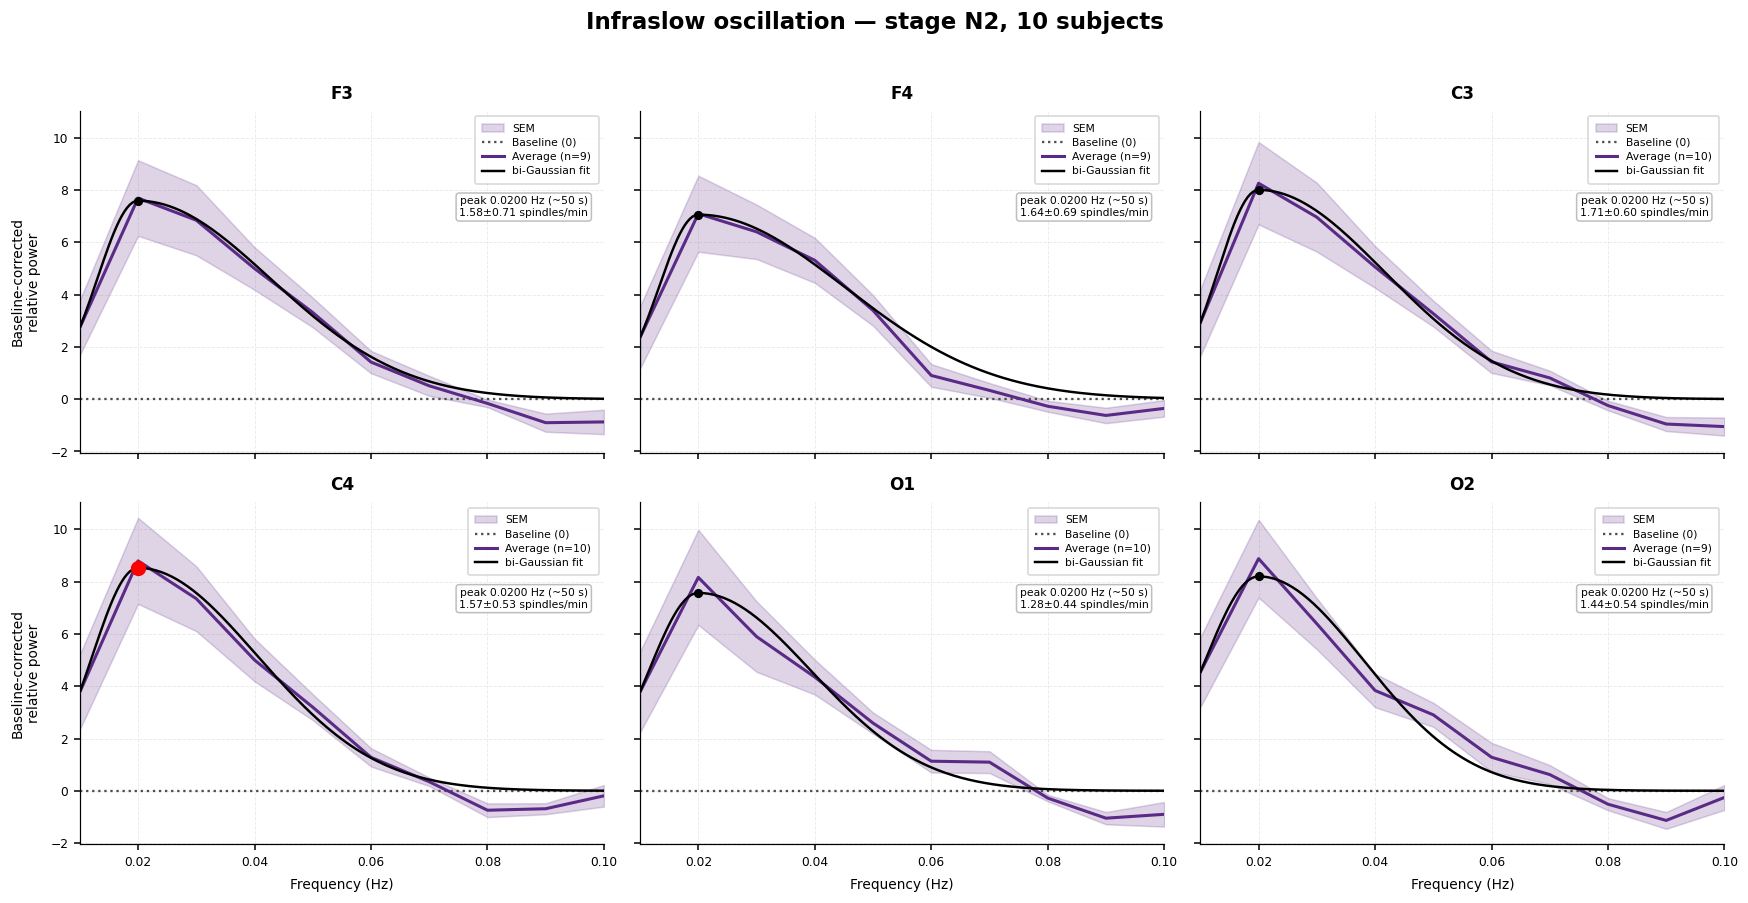

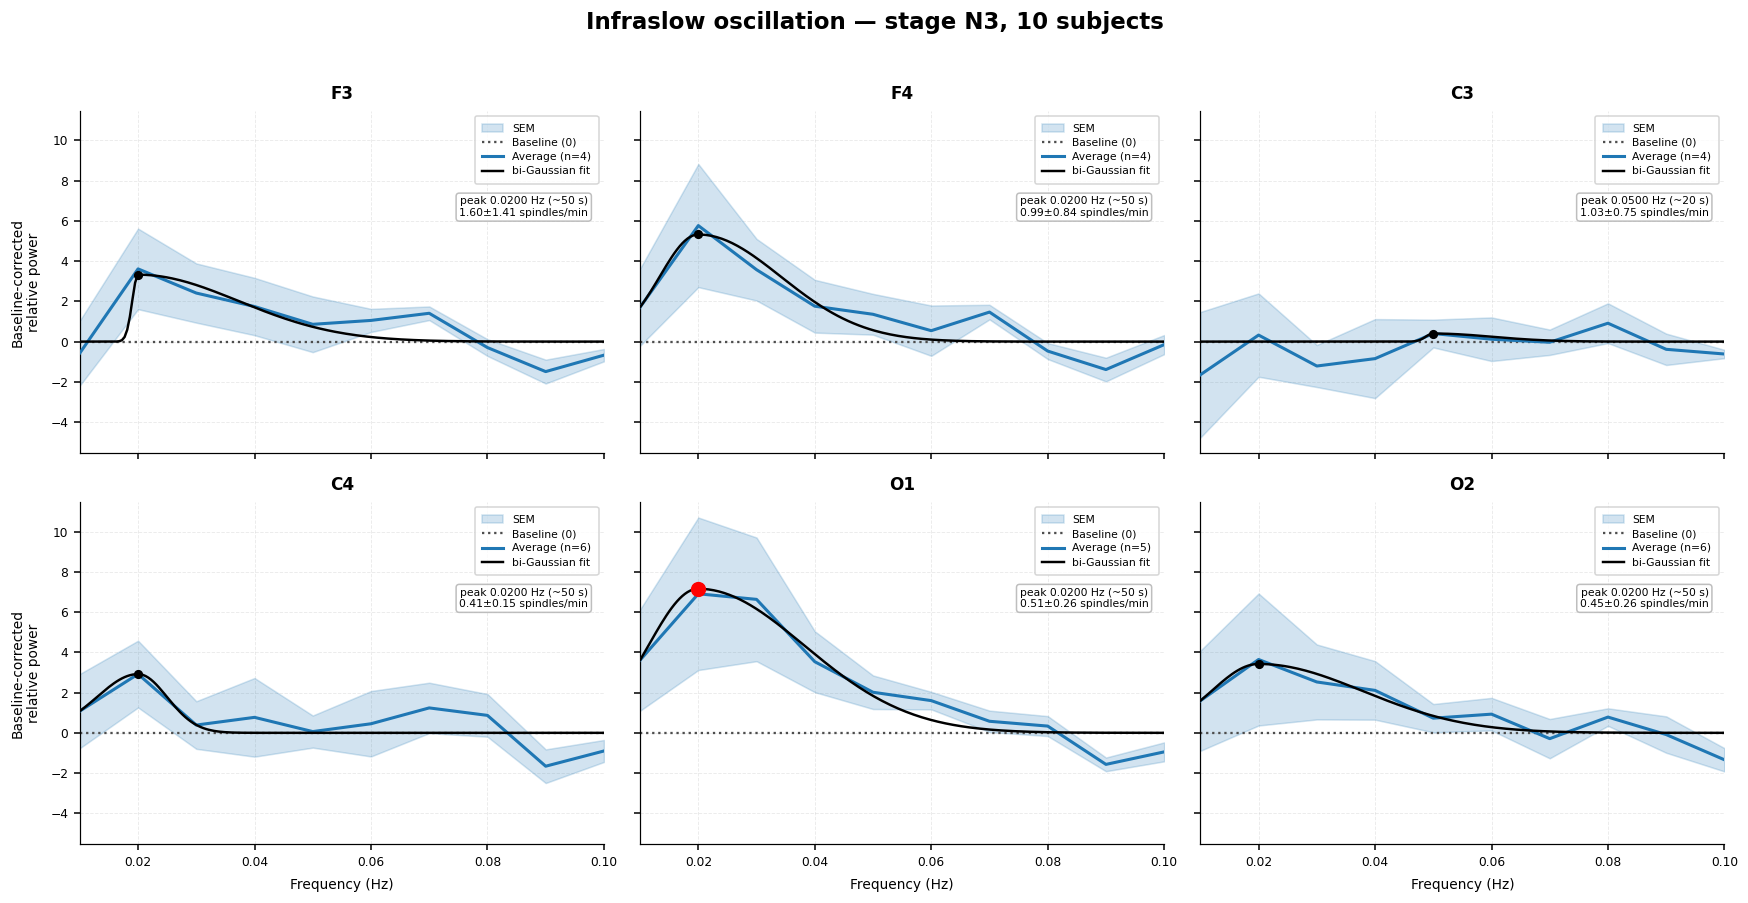

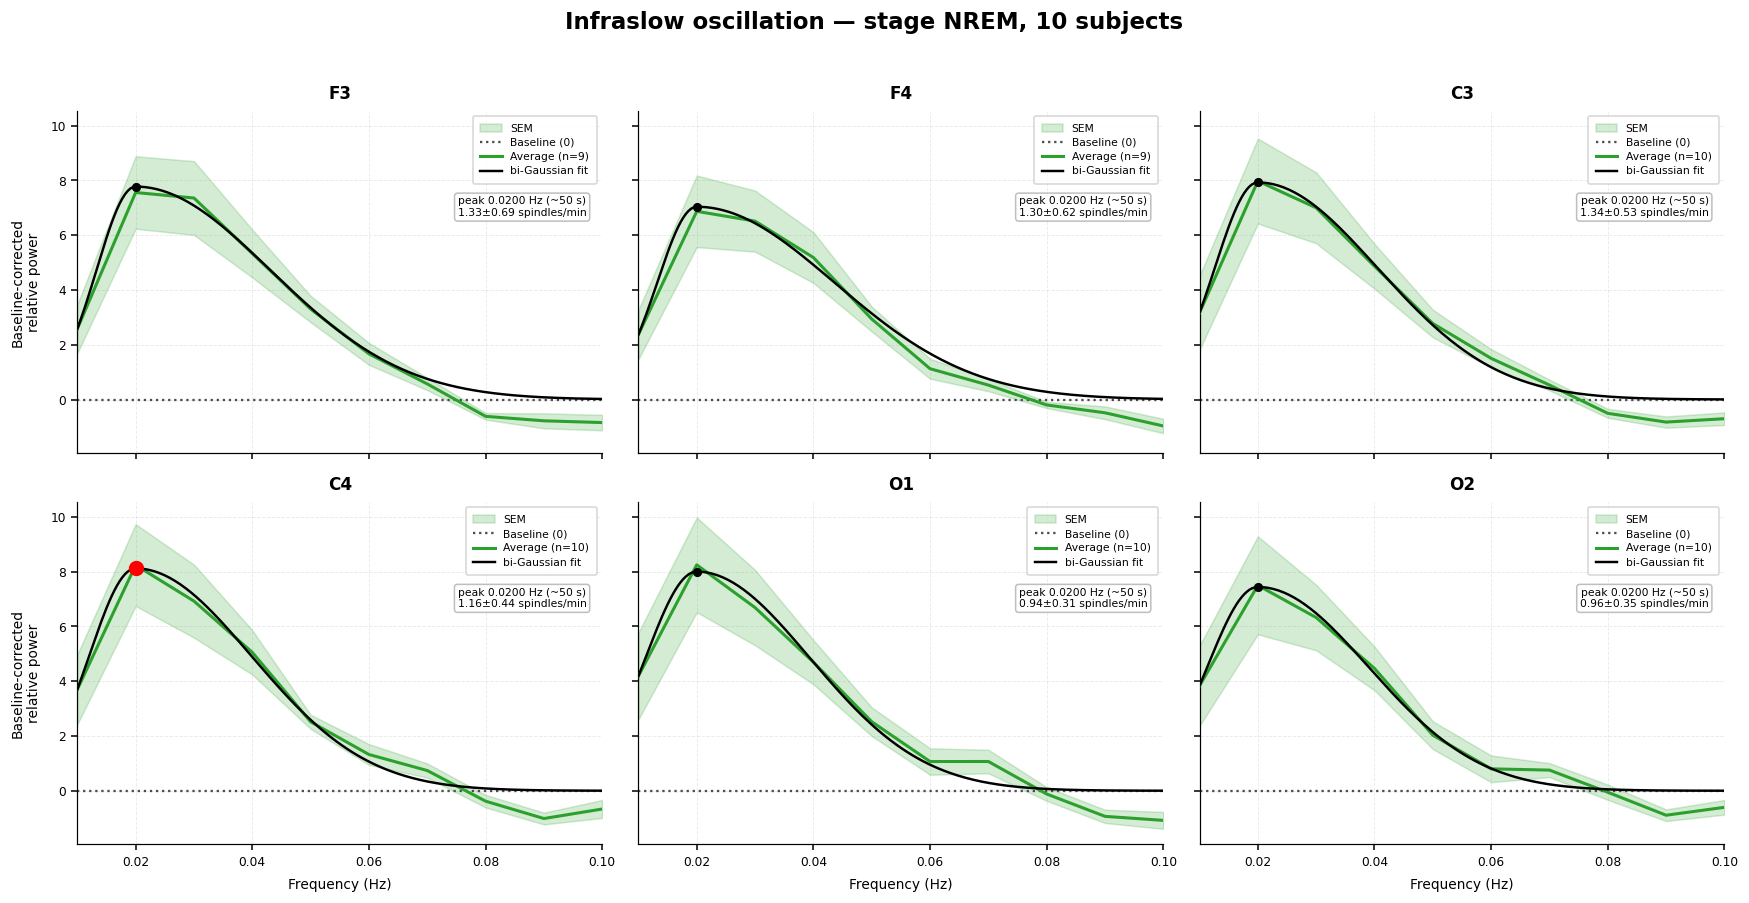

In [11]:
all_results = {}   # all_results[stage][channel] = {'fit':.., 'peak_area':.., 'n':.., 'spindle_per_min':..} or None

for stage in STAGES:
    by_channel = by_stage[stage]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
    results = {}
    for i, (ax, ch) in enumerate(zip(axes.flat, CHANNELS)):
        results[ch] = (ax, plot_channel_subplot(ax, by_channel[ch]['freqs'], by_channel[ch]['subjects'], ch,
                                                  color=STAGE_COLORS[stage],
                                                  spindle_rates=by_channel[ch]['spindle_rate'],
                                                  show_individual=SHOW_INDIVIDUAL,
                                                  show_legend=True))
    all_results[stage] = {ch: r for ch, (ax, r) in results.items()}

    for ax in axes[-1]:
        ax.set_xlabel('Frequency (Hz)', fontsize=LABEL_FONTSIZE, labelpad=6)
    for ax in axes[:, 0]:
        ax.set_ylabel('Baseline-corrected\nrelative power', fontsize=LABEL_FONTSIZE, labelpad=6)

    # Mark the channel with the highest fitted peak power (bi-Gaussian amplitude)
    # with a red dot on top of its (black) peak marker.
    valid_results = {ch: (ax, r) for ch, (ax, r) in results.items() if r is not None}
    if valid_results:
        max_ch, (max_ax, max_r) = max(valid_results.items(), key=lambda kv: kv[1][1]['fit']['amp'])
        max_ax.plot([max_r['fit']['mu']], [max_r['fit']['amp']], 'o', color='red', ms=9, zorder=6,
                    # label='max power channel'
                    )
        max_ax.legend(frameon=True, fontsize=LEGEND_FONTSIZE, borderpad=0.7,
                      labelspacing=0.4, loc='upper right')

    fig.suptitle(f'Infraslow oscillation — stage {stage}, {by_channel["_n_files"]} subjects',
                 y=1.02, fontsize=SUPTITLE_FONTSIZE, fontweight='bold')
    fig.tight_layout()
    plt.show()

## ISFS summary across stages and channels

In [5]:
summary = pd.DataFrame([
    {
        'stage': stage,
        'channel': ch,
        'n': r['n'],
        'peak_freq_hz': r['fit']['mu'],
        'peak_period_s': 1 / r['fit']['mu'],
        'bandwidth_hz': r['fit']['bandwidth'],
        'auc': r['fit']['auc'],
        'chromatogram_peak_area': r['peak_area'],
        'spindle_per_min': r['spindle_per_min'],
        'spindle_per_min_SEM': r['spindle_per_min_sem'],
        # 'detected': r['fit']['detected'],
    }
    for stage, by_ch in all_results.items()
    for ch, r in by_ch.items()
    if r is not None
]).set_index(['stage', 'channel'])
summary

n  peak_freq_hz  peak_period_s  bandwidth_hz       auc  \
stage channel                                                            
N1    F3        2          0.02      50.000000      0.020366  0.264418   
      F4        2          0.02      50.000000      0.027773  0.304570   
      C3        2          0.02      50.000000      0.030394  0.396858   
      C4        3          0.01     100.000000      0.038178  0.376210   
      O1        2          0.02      50.000000      0.078722  0.701285   
      O2        1          0.03      33.333333      0.026406  0.479876   
N2    F3        9          0.02      50.000000      0.029766  0.193370   
      F4        9          0.02      50.000000      0.031964  0.193060   
      C3       10          0.02      50.000000      0.028748  0.196935   
      C4       10          0.02      50.000000      0.028287  0.206380   
      O1       10          0.02      50.000000      0.027851  0.180378   
      O2        9          0.02      50.000000      0.027287  0.191459   
N3    F3        4          0.02      50.000000      0.018262  0.051962   
      F4        4          0.02      50.000000      0.020813  0.094784   
      C3        4          0.05      20.000000      0.011301  0.003878   
      C4        6          0.02      50.000000      0.012097  0.030219   
      O1        5          0.02      50.000000      0.026744  0.163837   
      O2        6          0.02      50.000000      0.025999  0.076131   
NREM  F3        9          0.02      50.000000      0.029869  0.198718   
      F4        9          0.02      50.000000      0.030399  0.183104   
      C3       10          0.02      50.000000      0.027876  0.189101   
      C4       10          0.02      50.000000      0.027820  0.193274   
      O1       10          0.02      50.000000      0.028173  0.192902   
      O2       10          0.02      50.000000      0.027692  0.176322   

               chromatogram_peak_area  spindle_per_min  spindle_per_min_SEM  
stage channel                                                                
N1    F3                     0.236317         0.329004             0.147186  
      F4                     0.129066         0.292929             0.070707  
      C3                     0.118243         0.538012             0.093567  
      C4                     0.029694         0.229918             0.030238  
      O1                     0.082189         0.311111             0.088889  
      O2                     0.543638         0.444444             0.000000  
N2    F3                     0.153064         1.578831             0.712568  
      F4                     0.166597         1.637613             0.691633  
      C3                     0.153423         1.712481             0.597225  
      C4                     0.150311         1.566058             0.532414  
      O1                     0.114421         1.279564             0.440125  
      O2                     0.113734         1.442268             0.539484  
N3    F3                     0.036100         1.598129             1.406522  
      F4                     0.071070         0.987003             0.835989  
      C3                     0.000123         1.032536             0.753882  
      C4                     0.013914         0.409666             0.151762  
      O1                     0.098265         0.505865             0.258355  
      O2                     0.041985         0.446766             0.255217  
NREM  F3                     0.160950         1.326684             0.686543  
      F4                     0.151932         1.304408             0.620308  
      C3                     0.142510         1.337022             0.531368  
      C4                     0.134443         1.155806             0.435784  
      O1                     0.118955         0.939229             0.305523  
      O2                     0.113536         0.960176             0.352193